In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy
import joblib
import os
import mlflow
import mlflow.sklearn

print("All imports successful ✅")

All imports successful ✅


In [2]:
ratings = pd.read_csv("../../Data/raw/ratings.csv")
movies  = pd.read_csv("../../Data/raw/movies.csv")

print(f"Ratings shape : {ratings.shape}")
print(f"Movies shape  : {movies.shape}")
print()
print(ratings.head())

Ratings shape : (100836, 4)
Movies shape  : (9742, 3)

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [3]:
# Tell Surprise the rating scale
reader = Reader(rating_scale=(0.5, 5.0))

# Load into Surprise format
data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

print("Data loaded into Surprise format ✅")
print(f"Total ratings: {len(ratings)}")

Data loaded into Surprise format ✅
Total ratings: 100836


In [4]:
# 80% train, 20% test
# random_state=42 makes results reproducible
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training samples : {trainset.n_ratings}")
print(f"Test samples     : {len(testset)}")

Training samples : 80668
Test samples     : 20168


In [ ]:
# Set up MLflow experiment tracking
mlflow.set_experiment("REC-AI-Models")

with mlflow.start_run(run_name="SVD-Collaborative-Filtering"):
    
    # Log hyperparameters
    mlflow.log_param("n_factors", 100)
    mlflow.log_param("n_epochs", 20)
    mlflow.log_param("lr_all", 0.005)
    mlflow.log_param("reg_all", 0.02)
    mlflow.log_param("dataset", "MovieLens-1M")
    mlflow.log_param("n_ratings", len(ratings))
    
    svd_model = SVD(
        n_factors=100,   # number of hidden patterns to learn
        n_epochs=20,     # how many times to go through the data
        lr_all=0.005,    # learning rate
        reg_all=0.02,    # regularization (prevents overfitting)
        random_state=42
    )

    print("Training SVD model... ⏳")
    svd_model.fit(trainset)
    print("Training complete ✅")
    
    # Make predictions on test set
    predictions = svd_model.test(testset)

    # RMSE = how far off predictions are on average
    # Lower is better — good score is < 0.90
    rmse = accuracy.rmse(predictions)
    mae  = accuracy.mae(predictions)
    
    # Log metrics
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)

    print(f"\nRMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    
    # Save model artifact
    mlflow.sklearn.log_model(svd_model, "svd_model")
    
    print("SVD run logged to MLflow ✅")

Training SVD model... ⏳
Training complete ✅


In [6]:
# Make predictions on test set
predictions = svd_model.test(testset)

# RMSE = how far off predictions are on average
# Lower is better — good score is < 0.90
rmse = accuracy.rmse(predictions)
mae  = accuracy.mae(predictions)

print(f"\nRMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

RMSE: 0.8807
MAE:  0.6766

RMSE : 0.8807
MAE  : 0.6766


In [7]:
# Tests across 5 different splits to prove model is consistent
results = cross_validate(
    SVD(n_factors=100, n_epochs=20, random_state=42),
    data,
    measures=['RMSE', 'MAE'],
    cv=5,
    verbose=True
)

print(f"\nAverage RMSE : {results['test_rmse'].mean():.4f}")
print(f"Average MAE  : {results['test_mae'].mean():.4f}")

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8764  0.8800  0.8692  0.8673  0.8728  0.8731  0.0047  
MAE (testset)     0.6706  0.6753  0.6706  0.6683  0.6702  0.6710  0.0023  
Fit time          0.34    0.31    0.32    0.32    0.33    0.32    0.01    
Test time         0.03    0.07    0.03    0.07    0.03    0.05    0.02    

Average RMSE : 0.8731
Average MAE  : 0.6710


In [8]:
# Predict what User 1 would rate Shawshank Redemption
user_id  = 1
movie_id = 318  # Shawshank Redemption

prediction = svd_model.predict(user_id, movie_id)

print(f"User         : {user_id}")
print(f"Movie ID     : {movie_id}")
print(f"Predicted ⭐ : {prediction.est:.2f}")

User         : 1
Movie ID     : 318
Predicted ⭐ : 4.92


In [9]:
def get_top_n_recommendations(model, user_id, ratings_df, movies_df, n=10):
    # Movies this user has already rated
    rated_movies   = ratings_df[ratings_df['userId'] == user_id]['movieId'].tolist()
    all_movies     = movies_df['movieId'].tolist()
    unrated_movies = [m for m in all_movies if m not in rated_movies]

    # Predict rating for every unrated movie
    predictions = [
        (movie_id, model.predict(user_id, movie_id).est)
        for movie_id in unrated_movies
    ]

    # Sort by predicted rating descending, take top N
    top_n = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

    # Add movie titles
    results = []
    for movie_id, predicted_rating in top_n:
        title = movies_df[movies_df['movieId'] == movie_id]['title'].values[0]
        results.append({
            'movieId'          : movie_id,
            'title'            : title,
            'predicted_rating' : round(predicted_rating, 2)
        })

    return pd.DataFrame(results)


# Get recommendations for User 1
recs = get_top_n_recommendations(
    model      = svd_model,
    user_id    = 1,
    ratings_df = ratings,
    movies_df  = movies
)

print("🎬 Top 10 Recommendations for User 1:")
print(recs.to_string(index=False))

🎬 Top 10 Recommendations for User 1:
 movieId                                                                       title  predicted_rating
     541                                                         Blade Runner (1982)               5.0
     741                                  Ghost in the Shell (Kôkaku kidôtai) (1995)               5.0
     750 Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)               5.0
     908                                                   North by Northwest (1959)               5.0
     912                                                           Casablanca (1942)               5.0
    1104                                            Streetcar Named Desire, A (1951)               5.0
    1172                              Cinema Paradiso (Nuovo cinema Paradiso) (1989)               5.0
    1193                                      One Flew Over the Cuckoo's Nest (1975)               5.0
    1204                            

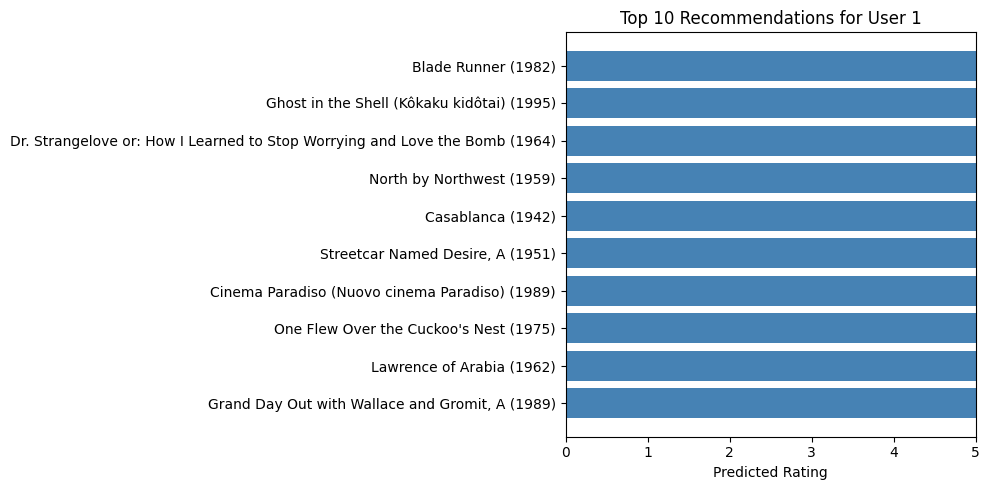

In [10]:
plt.figure(figsize=(10, 5))
plt.barh(recs['title'], recs['predicted_rating'], color='steelblue')
plt.xlabel("Predicted Rating")
plt.title("Top 10 Recommendations for User 1")
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
os.makedirs("../../backend/saved_models", exist_ok=True)
joblib.dump(svd_model, "../../backend/saved_models/svd_model.pkl")

print("Model saved ✅")
print("Saved to: backend/saved_models/svd_model.pkl")

Model saved ✅
Saved to: backend/saved_models/svd_model.pkl
